In [3]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os
from pathlib import Path

load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

DATASET_PATH = Path("data") / "csgo"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("jgers-workspace").project("csgo-train-yolo-v5-u8bfj")
dataset = project.version(1).download("yolov5", location=DATASET_PATH)


loading Roboflow workspace...
loading Roboflow project...


In [4]:
from PIL import Image
import torch
from torch.utils.data import Dataset

class CSGODataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.image_dir = self.root / "images"
        self.label_dir = self.root / "labels"
        self.images = sorted(self.image_dir.glob("*.*"))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert("RGB")

        # Load YOLO label: class_id, x_center, y_center, width, height
        label_path = self.label_dir / f"{img_path.stem}.txt"
        boxes = []
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    coords = list(map(float, parts[1:5]))
                    boxes.append([class_id, *coords])

        target = torch.tensor(boxes) if boxes else torch.zeros((0, 5))

        if self.transform:
            image = self.transform(image)

        return image, target

In [5]:
train_dataset = CSGODataset(DATASET_PATH / "train")
val_dataset = CSGODataset(DATASET_PATH / "valid")
test_dataset = CSGODataset(DATASET_PATH / "test")

In [8]:
from ultralytics import YOLO

model_path = Path("models")

model = YOLO("yolov5su.pt")
model.train(data=DATASET_PATH / "data.yaml", epochs=50, imgsz=512, project=model_path, name="csgo-yolov5")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+rocm7.1 CUDA:0 (AMD Radeon RX 7700 XT, 12272MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/csgo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5su.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=csgo-yolov5-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f76a9e7bb30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [10]:
best_model_path = Path("runs") / "detect" / model_path / "csgo-yolov5-2" / "weights" / "best.pt"

best_model = YOLO(best_model_path)
# Specify to run it on the test data otherwise it will default to
metrics = best_model.val(data=DATASET_PATH / "data.yaml", split="test")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+rocm7.1 CUDA:0 (AMD Radeon RX 7700 XT, 12272MiB)
YOLOv5s summary (fused): 85 layers, 9,112,697 parameters, 0 gradients, 23.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2233.3±508.6 MB/s, size: 31.1 KB)
val: Scanning /home/philip/Projects/ML-Assignment-3/data/csgo/test/labels... 207 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 5.4Kit/s 0.0s
val: New cache created: /home/philip/Projects/ML-Assignment-3/data/csgo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.8s/it 23.4s<0.1s
                   all        207        229      0.958      0.941      0.964      0.627
                    CT        175        188      0.988      0.906      0.941      0.611
                     T         35         41      0.927      0.976      0.988      0.644
Speed: 0.3ms preprocess, 111.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Result

In [23]:
print(f"mAP@0.5:0.95  -  {metrics.box.map}")
print(f"mAP@0.5       -  {metrics.box.map50}")
print(f"mAP@0.75      -  {metrics.box.map75}")

print()

print("mAP@0.5:0.95 per class")
for i, class_map in enumerate(metrics.box.maps):
    print(f"{metrics.names[i]:8s}-  {class_map:.4f}")

mAP@0.5:0.95  -  0.6274329328104057
mAP@0.5       -  0.9643760503541934
mAP@0.75      -  0.7545832288921112

mAP@0.5:0.95 per class
CT      -  0.6106
T       -  0.6443
person  -  0.6274


0.5 means that the boxes needs to match the true boxes by 50% and 0.75 means that the boxes can only be off by 75%, and 0.5:0.95 means that it counts the boxes off by 50% as correct but awards more if the boxes are closer to the true boxes

As a rough guide for what's "good":

- mAP@0.5 > 0.7 — decent
- mAP@0.5 > 0.85 — solid
- mAP@0.5:0.95 > 0.5 — good
- mAP@0.5:0.95 > 0.65 — very strong


0: 512x512 1 T, 1.9ms
1: 512x512 1 CT, 1.9ms
2: 512x512 1 CT, 1.9ms
3: 512x512 1 T, 1.9ms
4: 512x512 (no detections), 1.9ms
Speed: 0.4ms preprocess, 1.9ms inference, 0.3ms postprocess per image at shape (1, 3, 512, 512)


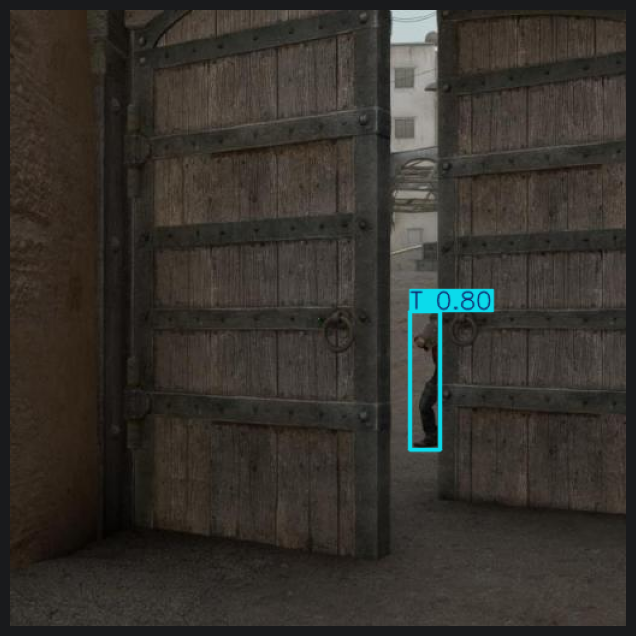

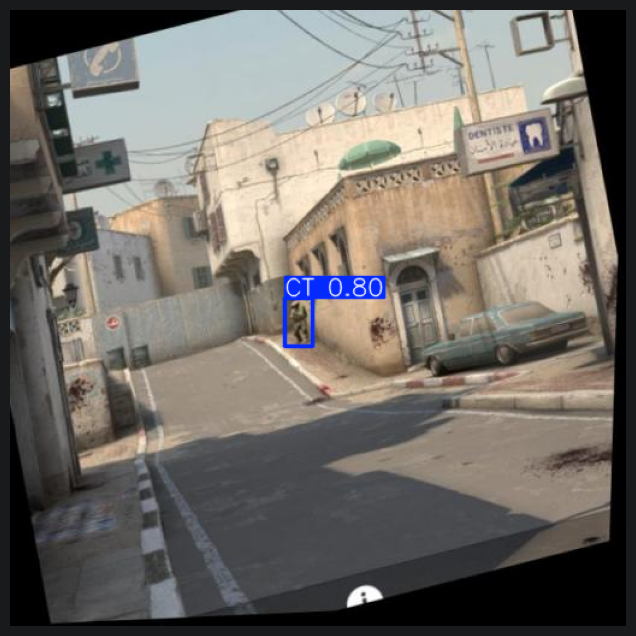

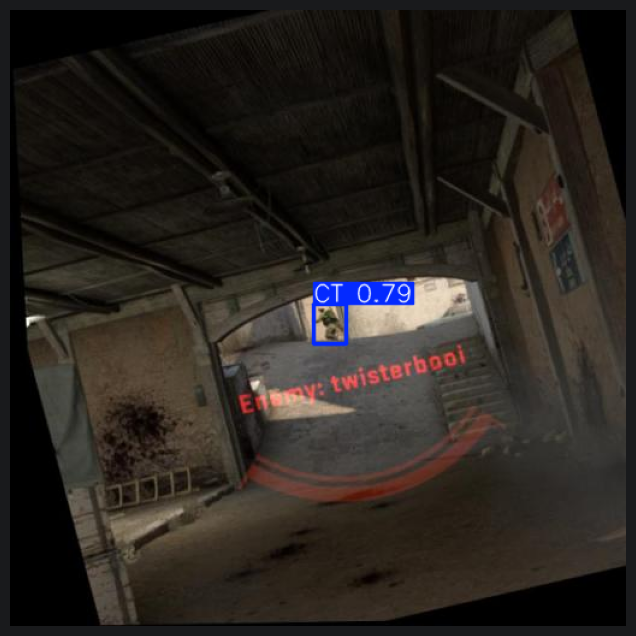

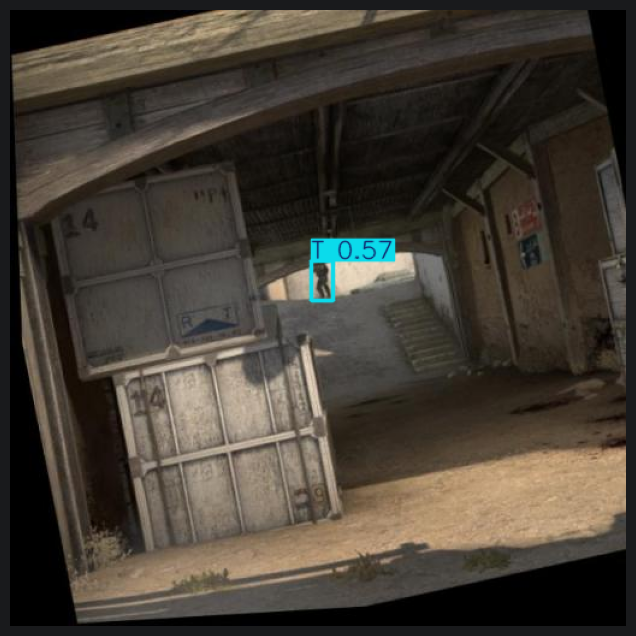

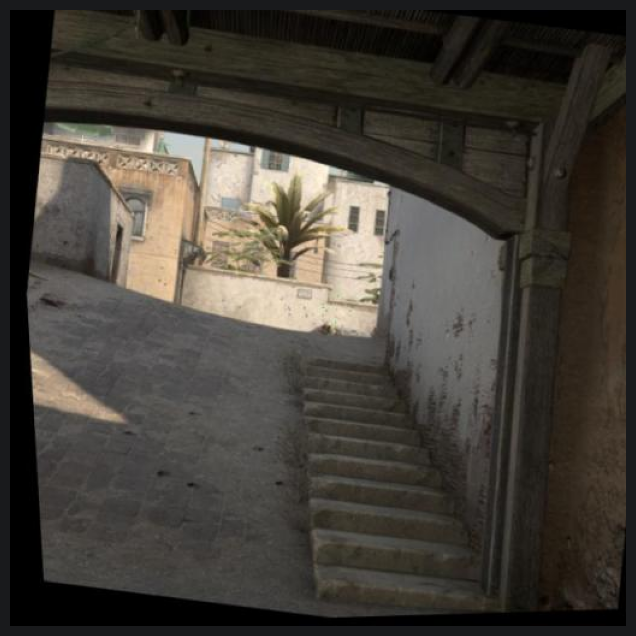

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

test_images = list(Path("data/csgo/test/images").glob("*.*"))[:5]

results = model.predict(test_images, conf=0.5)

for result in results:
    img = result.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(img[..., ::-1])
    plt.axis("off")
    plt.show()

As seen, the test images are augmented which isn't my fault but rather the original creator of the dataset's fault. It isn't a big deal but im just writing it down to show that im aware of it.
Although the predictions are look very good, except the last image which is really hard for even me to spot the CT.